Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

══════════════════════════════════════════════════════════════════════
  3.1  ĐỌC & FEATURE ENGINEERING
══════════════════════════════════════════════════════════════════════
Đọc từ: /content/drive/MyDrive/DM/outputs/df_feature_engineered.csv
Shape: (64374, 17) | Columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn', 'Usage_per_Tenure', 'Spend_per_Tenure', 'Support_per_Tenure', 'Support_x_Delay', 'Age_x_Tenure', 'Age_Group']

══════════════════════════════════════════════════════════════════════
  3.2  DEFINE FEATURES & TARGET
══════════════════════════════════════════════════════════════════════
Numeric   (12): ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Usage_per_Tenure', 'Spen

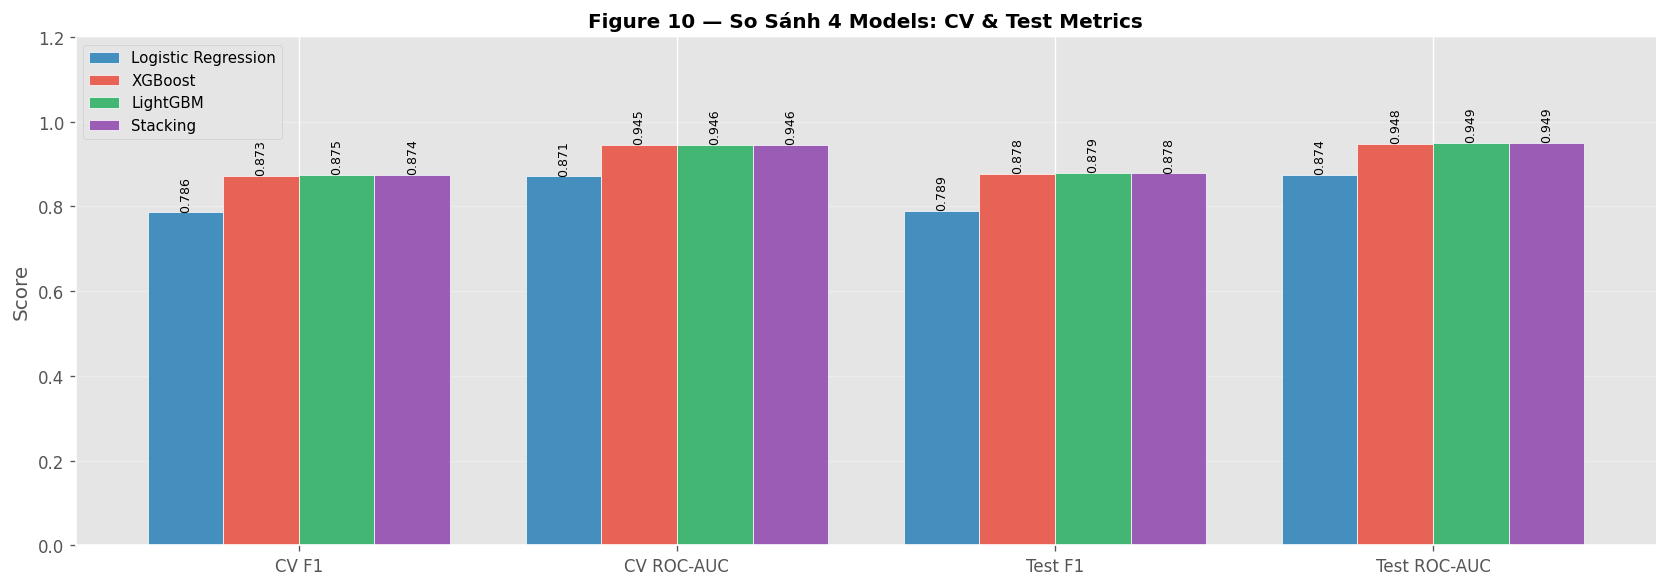


══════════════════════════════════════════════════════════════════════
  4.4  ROC, PR, Calibration, Confusion Matrix
══════════════════════════════════════════════════════════════════════


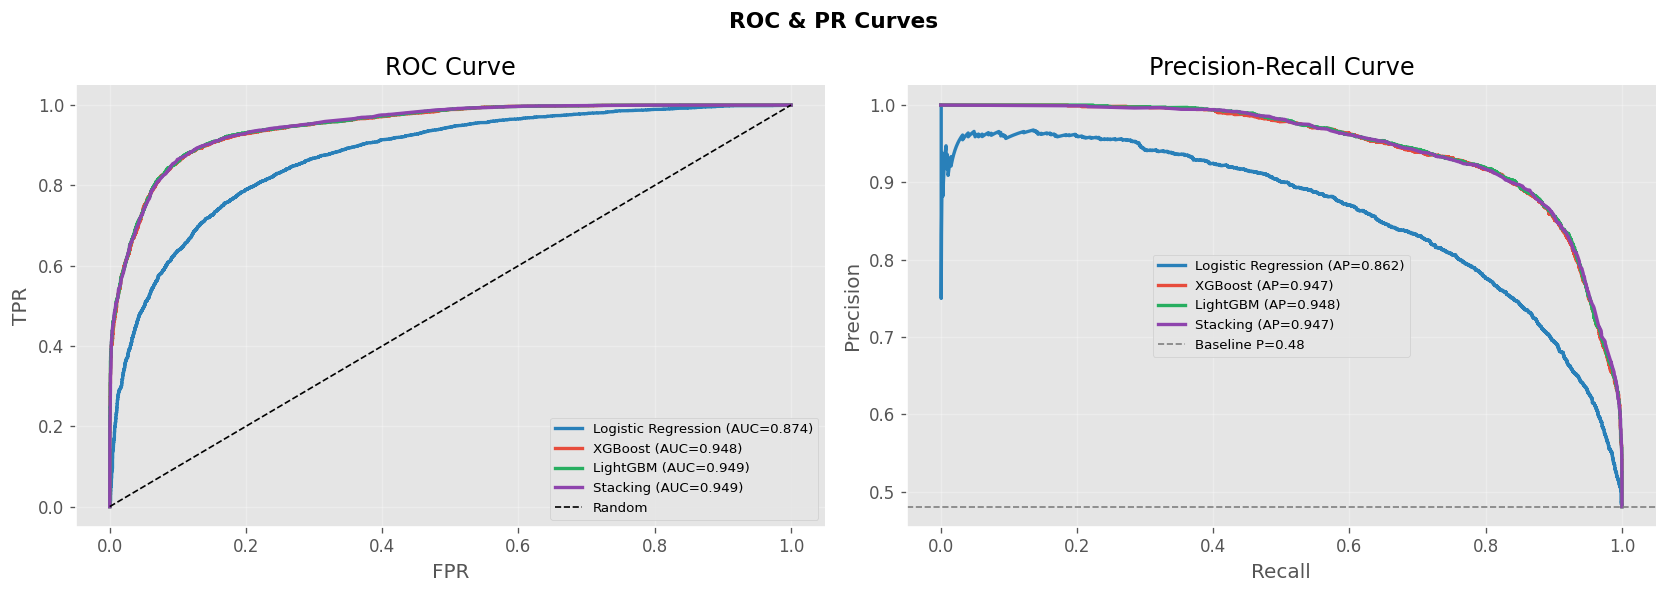

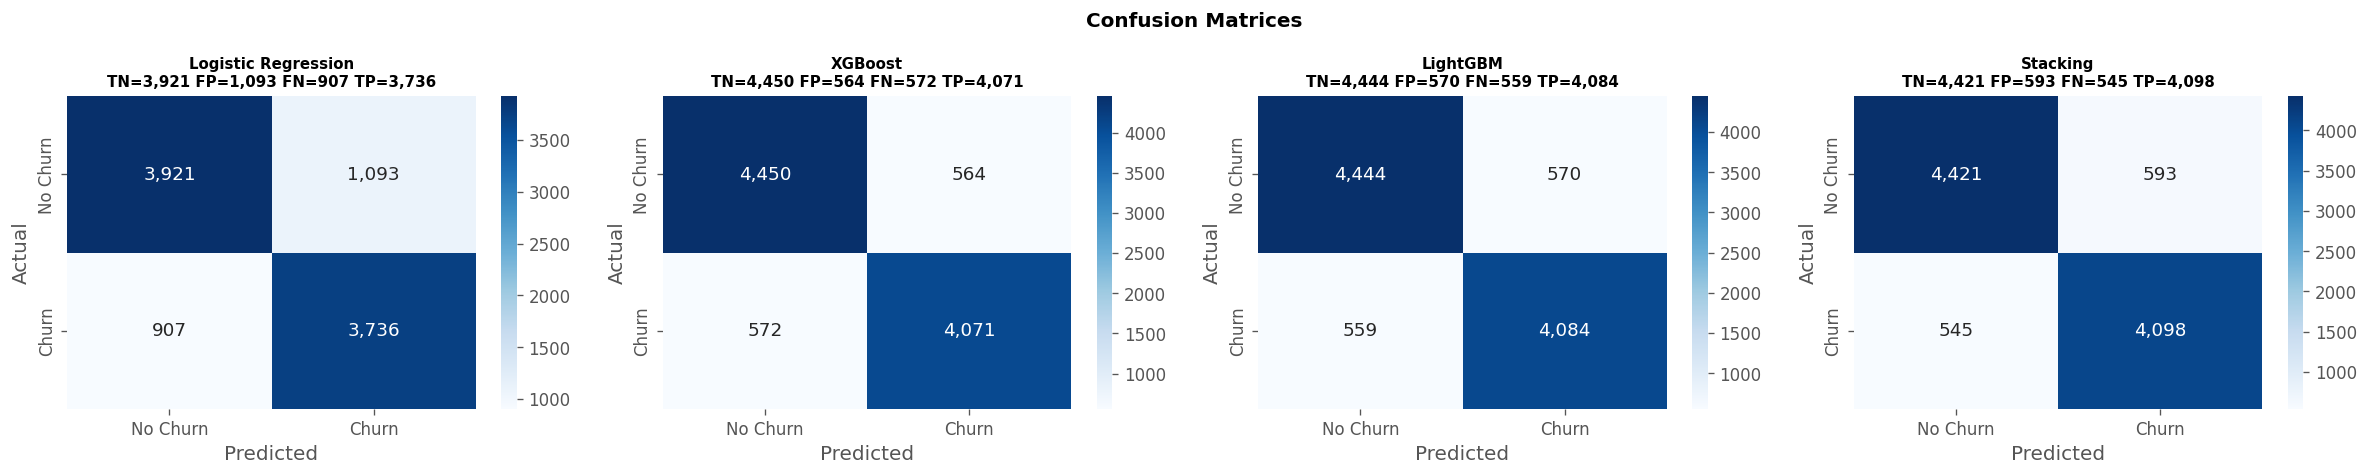

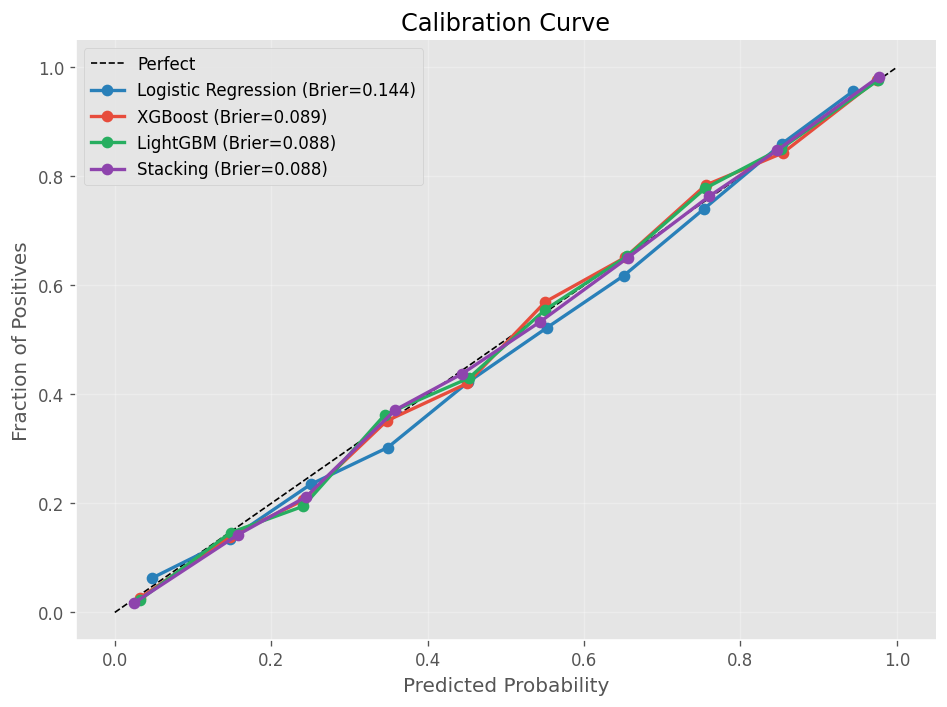

✅ Saved logistic_regression_base.pkl
✅ Saved xgboost_base.pkl
✅ Saved lightgbm_base.pkl
✅ Saved stacking_base.pkl

══════════════════════════════════════════════════════════════════════
  5.1  [OPTUNA] BAYESIAN HYPERPARAMETER OPTIMIZATION
══════════════════════════════════════════════════════════════════════
Best single model (CV F1): LightGBM = 0.8746
→ Optuna tune: LightGBM  (n_trials=50, TPE sampler)
  Cost matrix: FN=$500 | FP=$20 | ratio=25x



  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best Val F1: 0.8718
Best params:
  n_estimators: 520
  num_leaves: 55
  learning_rate: 0.12818867580053647
  subsample: 0.7419849065172623
  colsample_bytree: 0.9993194371465008
  min_child_samples: 19
  reg_alpha: 0.010134459012329216
  reg_lambda: 0.7413951008685175


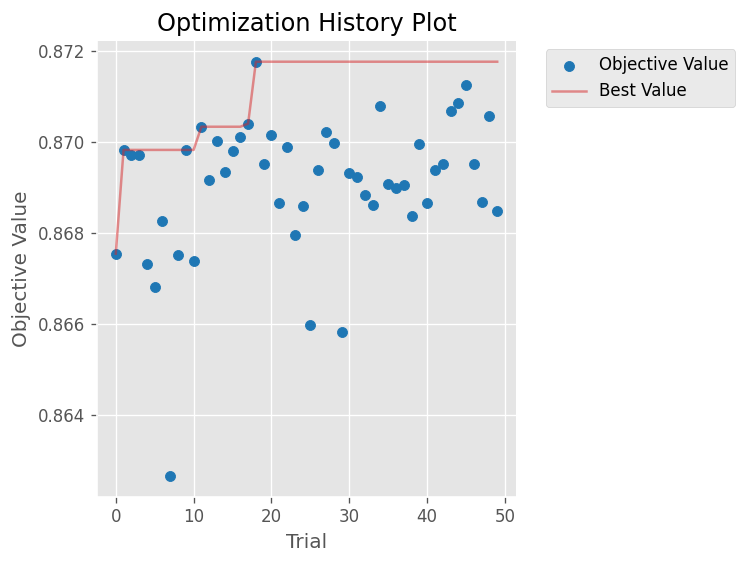

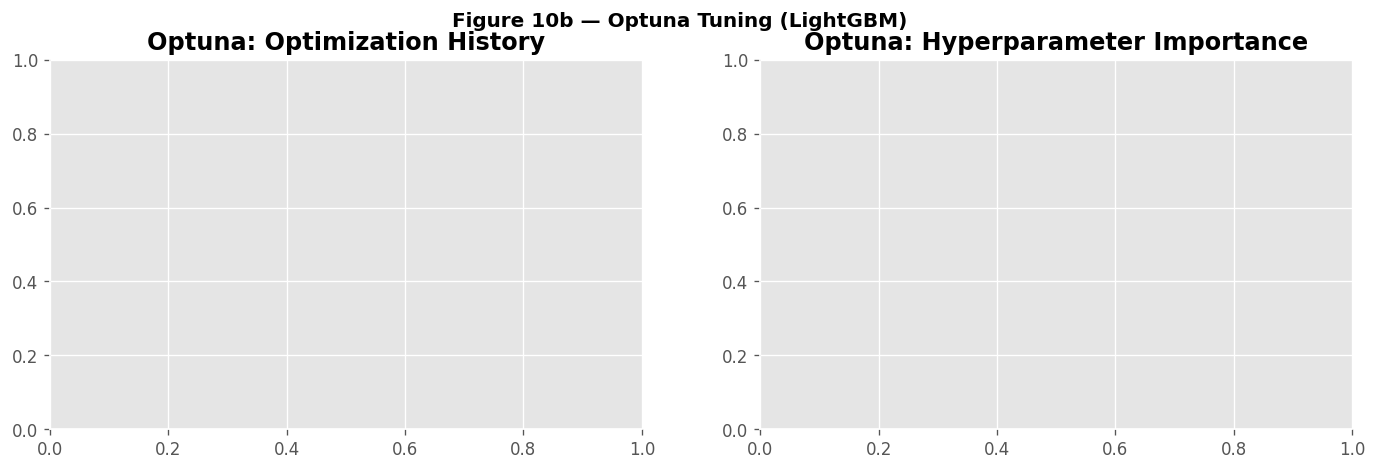

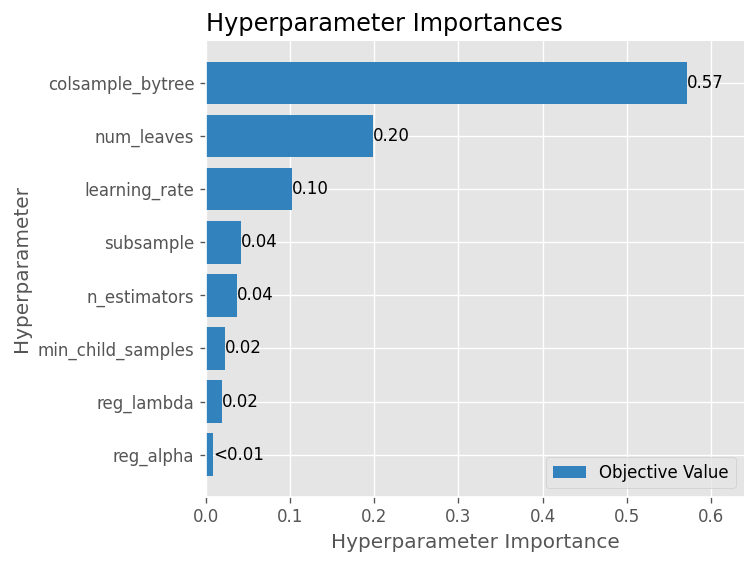


══════════════════════════════════════════════════════════════════════
  5.2  ĐÁNH GIÁ AFTER OPTUNA
══════════════════════════════════════════════════════════════════════

Metric                       Base   After Optuna          Δ
------------------------------------------------------------
Test F1                    0.8786         0.8800    +0.0014
Test AUC                   0.9491         0.9493    +0.0003

  ℹ️  Cải thiện nhỏ — base model gần bão hòa với data này.

══════════════════════════════════════════════════════════════════════
  5.3  [PROFIT-CURVE] THRESHOLD OPTIMIZATION
══════════════════════════════════════════════════════════════════════
[Val] Max-Profit threshold  : 0.069  ← business-optimal (FN=$500, FP=$20)
  ⚠️  Threshold quá thấp (0.07) → FP rất cao, cân nhắc dùng max-F1 (0.48) cho production
  → Override: dùng max-F1 threshold = 0.48 thay thế
[Val] Max-F1 threshold      : 0.479
[Val] Recall≥0.8 threshold: 0.665

Threshold                           F1  Recall    Pr

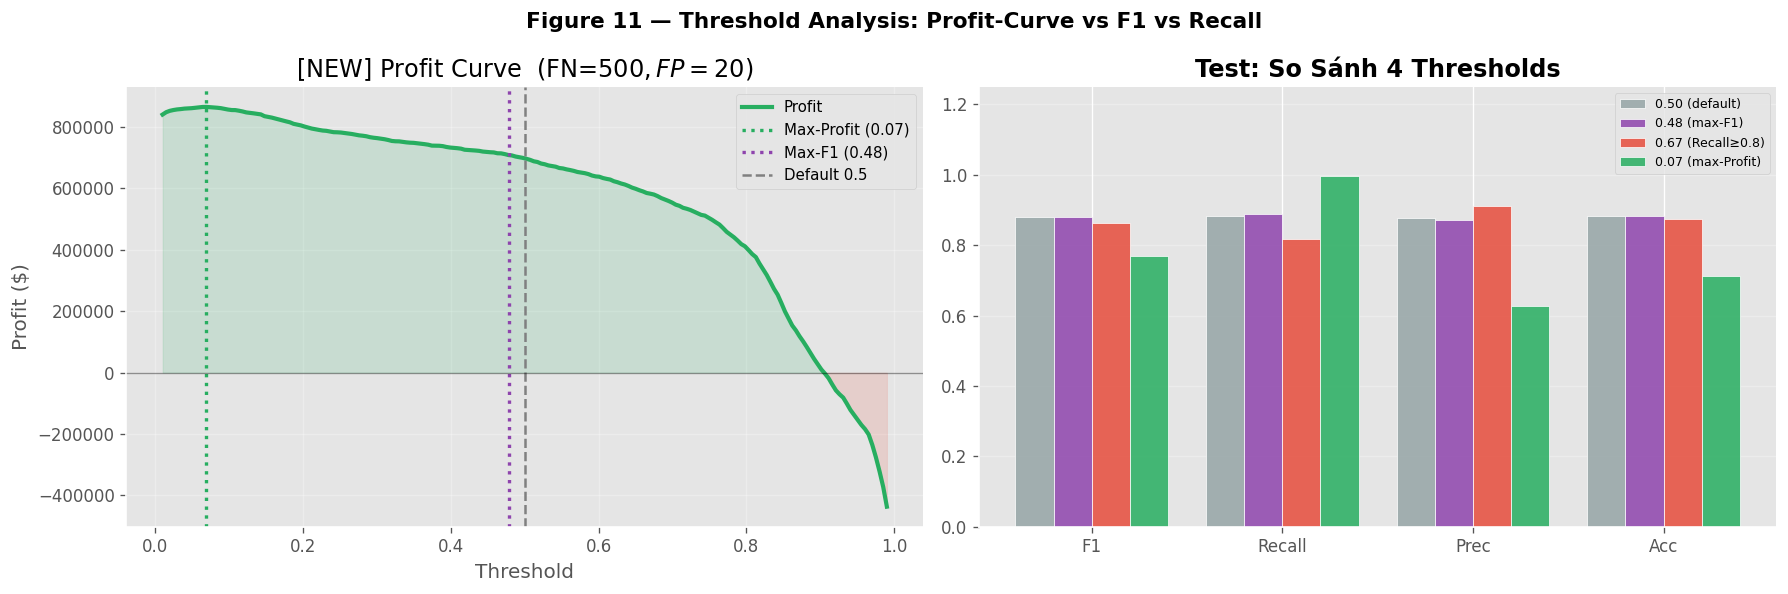


══════════════════════════════════════════════════════════════════════
  5.4  FULL COMPARISON: Base → Optuna → Threshold Moved
══════════════════════════════════════════════════════════════════════
Stage                                              F1  Recall     AUC       Profit
────────────────────────────────────────────────────────────────────────────────
1. Base LightGBM                               0.8786  0.8796  0.9491      698,020
2. Optuna tuned (th=0.50)                      0.8800  0.8820  0.9493      698,020
3. th=0.48 (max-F1)                            0.8795  0.8876  0.9493      707,660
3. th=0.67 (Recall≥0.8)                        0.8626  0.8189  0.9493      584,800
3. th=0.07 (max-Profit)                        0.7692  0.9955  0.9493      865,160  ◀

══════════════════════════════════════════════════════════════════════
  5.5  [CALIBRATION] ISOTONIC vs SIGMOID — CHỌN BRIER TỐT HƠN
══════════════════════════════════════════════════════════════════════

Method       

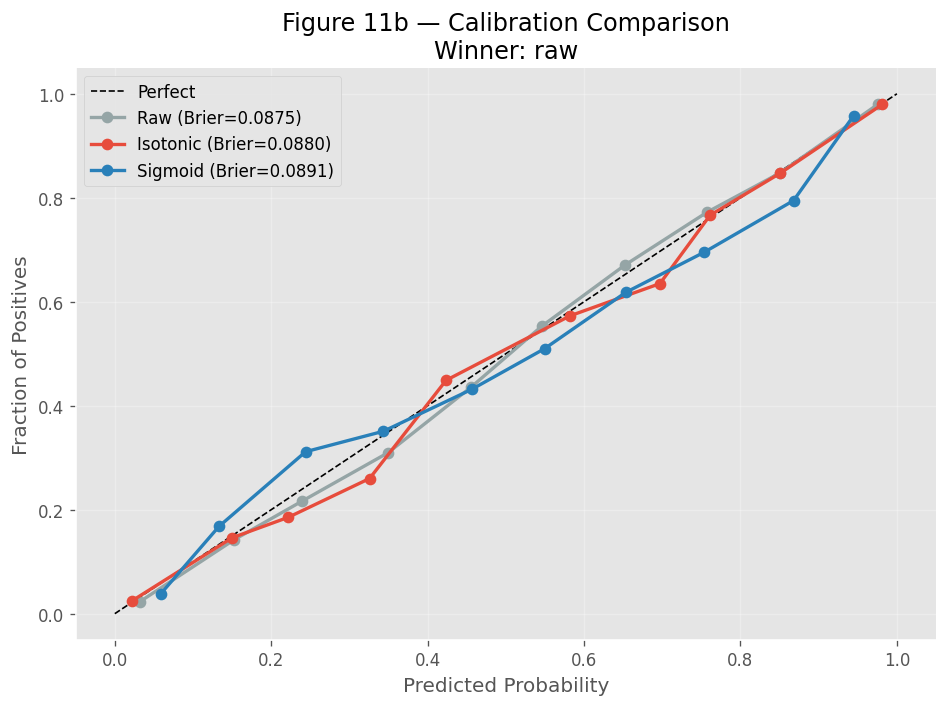


══════════════════════════════════════════════════════════════════════
  5.6  [PERMUTATION IMPORTANCE] VALIDATE FEATURES
══════════════════════════════════════════════════════════════════════
⏳ Computing permutation importance (n_repeats=10)...

Feature                           PI Mean   PI Std  Signal
-----------------------------------------------------------------
  Payment Delay                   0.16127  0.00315  ✅ Useful
  Support_x_Delay                 0.06717  0.00146  ✅ Useful
  Tenure                          0.05406  0.00143  ✅ Useful
  Gender_Male                     0.04702  0.00088  ✅ Useful
  Usage Frequency                 0.03309  0.00196  ✅ Useful
  Total Spend                     0.01670  0.00067  ✅ Useful
  Contract Length_Monthly         0.01627  0.00081  ✅ Useful
  Support Calls                   0.01587  0.00109  ✅ Useful
  Age                             0.01445  0.00085  ✅ Useful
  Support_per_Tenure              0.00149  0.00027  ⚠️  Weak
  Contract Length_

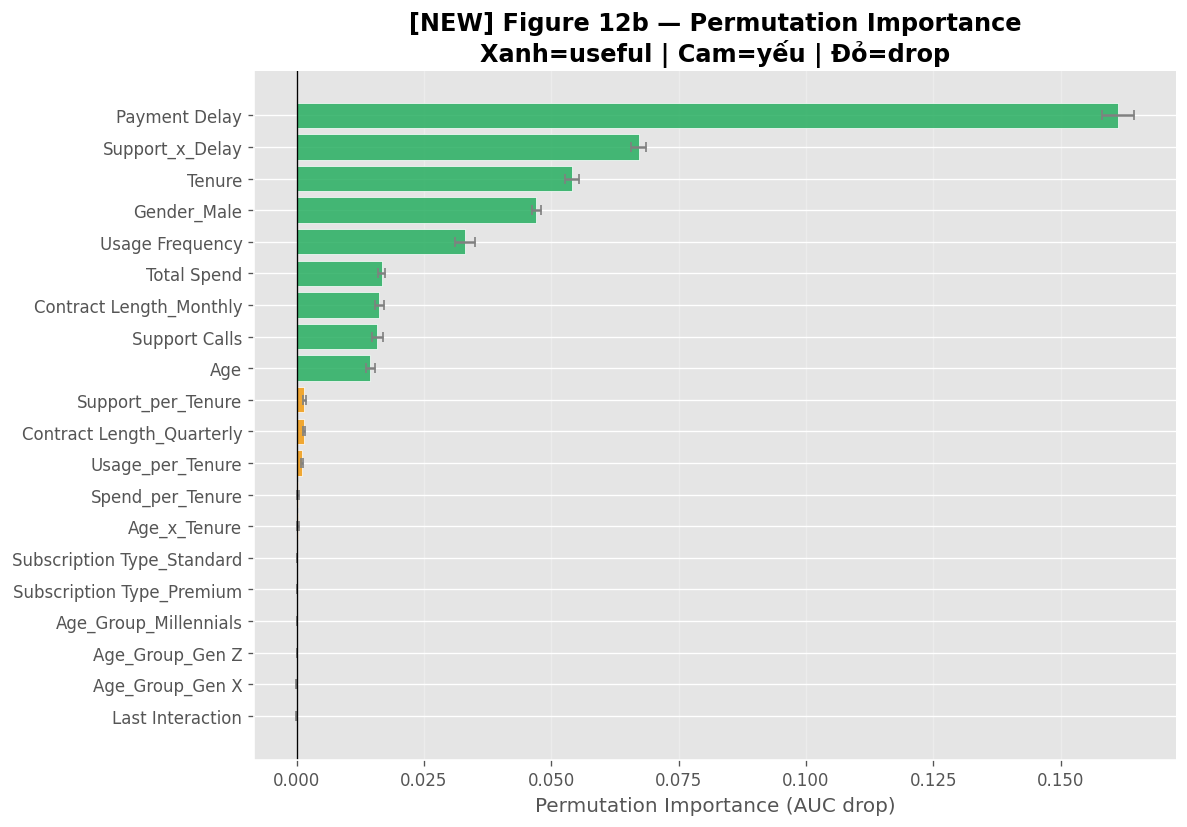


══════════════════════════════════════════════════════════════════════
  5.7  SAVE MODELS & CONFIG
══════════════════════════════════════════════════════════════════════
✅ Saved: tuned_model.pkl, tuned_calibrated_model.pkl, permutation_importance.pkl, model_config.json

══════════════════════════════════════════════════════════════════════
  6.1  SHAP FEATURE IMPORTANCE
══════════════════════════════════════════════════════════════════════
SHAP type: tree | Shape: (9657, 20)


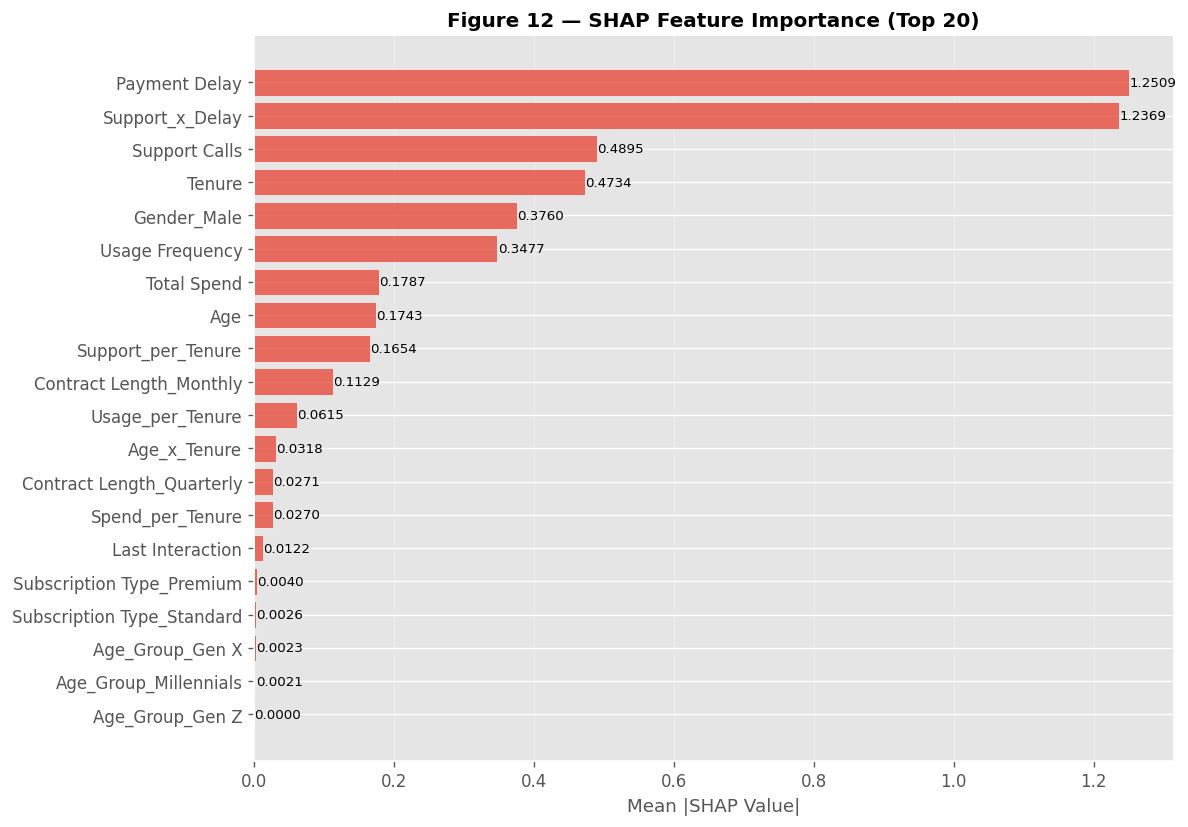

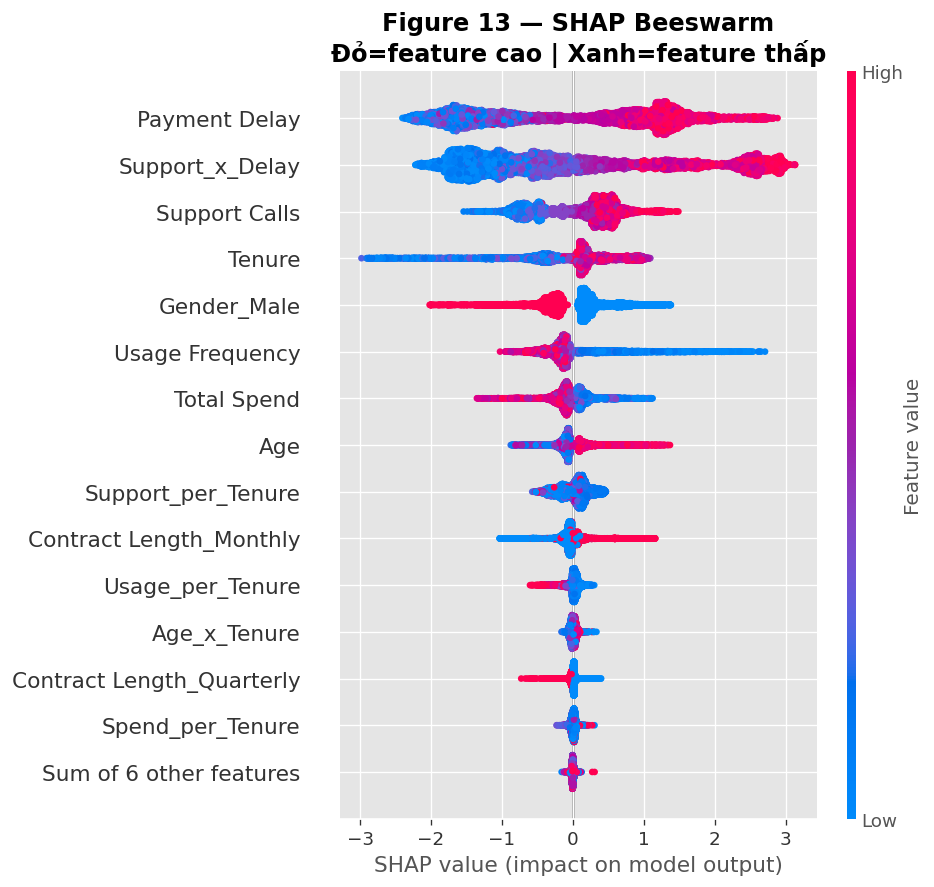

✅ SHAP hoàn thành.

══════════════════════════════════════════════════════════════════════
  6.2  BUSINESS INTERPRETATION
══════════════════════════════════════════════════════════════════════
┌────────────────────────────────────────────────────────────────────────────┐
│  BUSINESS INTERPRETATION — YẾU TỐ ẢNH HƯỞNG CHURN MẠNH NHẤT               │
│    Dựa trên SHAP values thực tế của model:
                               │
│    1. PAYMENT DELAY                                                       │
│       → Trễ thanh toán → dấu hiệu tài chính hoặc bất mãn                  │
│       → Action: Flexible payment plan, không phạt lần đầu
                │
│    2. SUPPORT CALLS / SUPPORT_PER_TENURE                                  │
│       → Gọi hỗ trợ nhiều → vấn đề chưa được giải quyết                    │
│       → Action: Proactive support — chỉ định Customer Success Manager riêng
│
│    3. TENURE / *_PER_TENURE                                               │
│       → Tenure ngắn + 

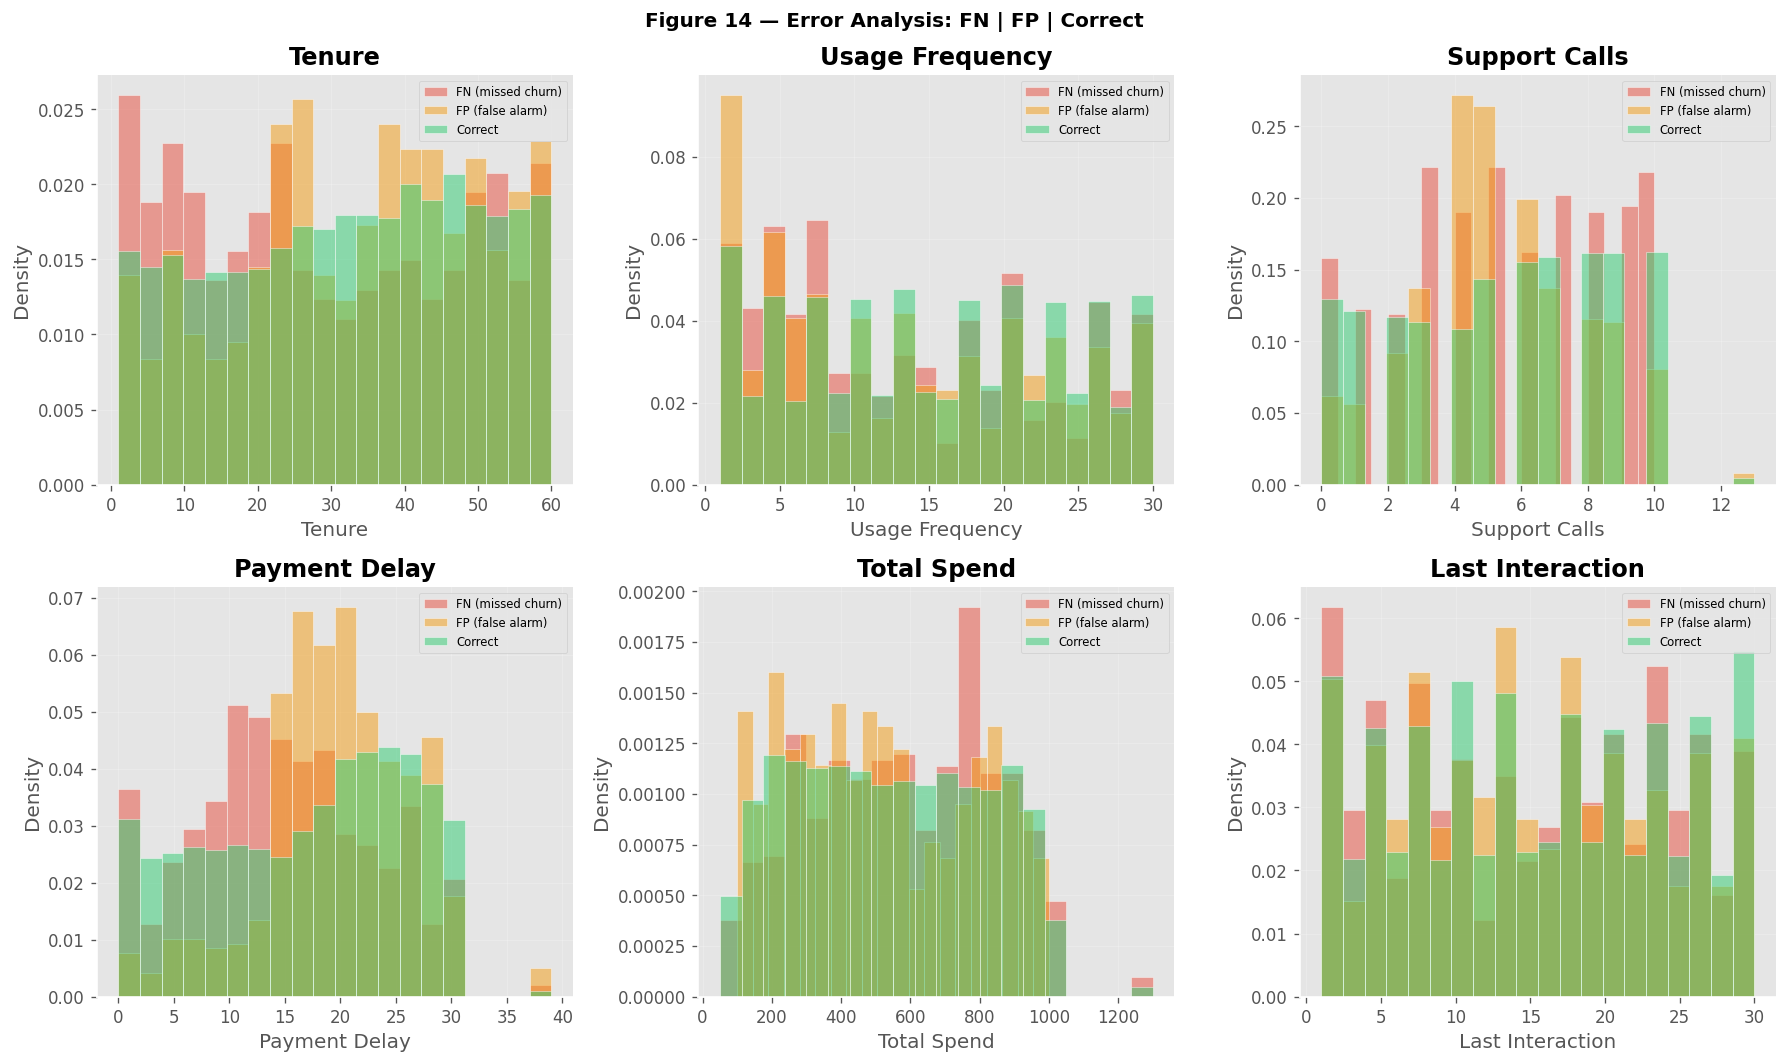


--- Common Patterns in False Negatives ---
  FN=522  TP=4,121  (Actual Positive=4,643)

  Feature                      FN mean    TP mean           Δ  Direction
  ────────────────────────────────────────────────────────────────────
  Tenure                         29.18      36.40       -7.22  ↓ FN thấp hơn
  Usage Frequency                13.64      14.16       -0.52  ↓ FN thấp hơn
  Support Calls                   5.36       6.55       -1.18  ↓ FN thấp hơn
  Payment Delay                  14.76      22.79       -8.03  ↓ FN thấp hơn
  Total Spend                   580.42     523.68      +56.74  ↑ FN cao hơn
  Last Interaction               14.99      15.53       -0.54  ↓ FN thấp hơn

  💡 Insight:
  Feature phân biệt FN rõ nhất: 'Total Spend' (FN cao hơn TP 56.74 đơn vị)
  19% FN có Support Calls < 3 → 'silent churners'

══════════════════════════════════════════════════════════════════════
  6.4  SO SÁNH GỐC vs CẢI TIẾN
════════════════════════════════════════════════════════════════

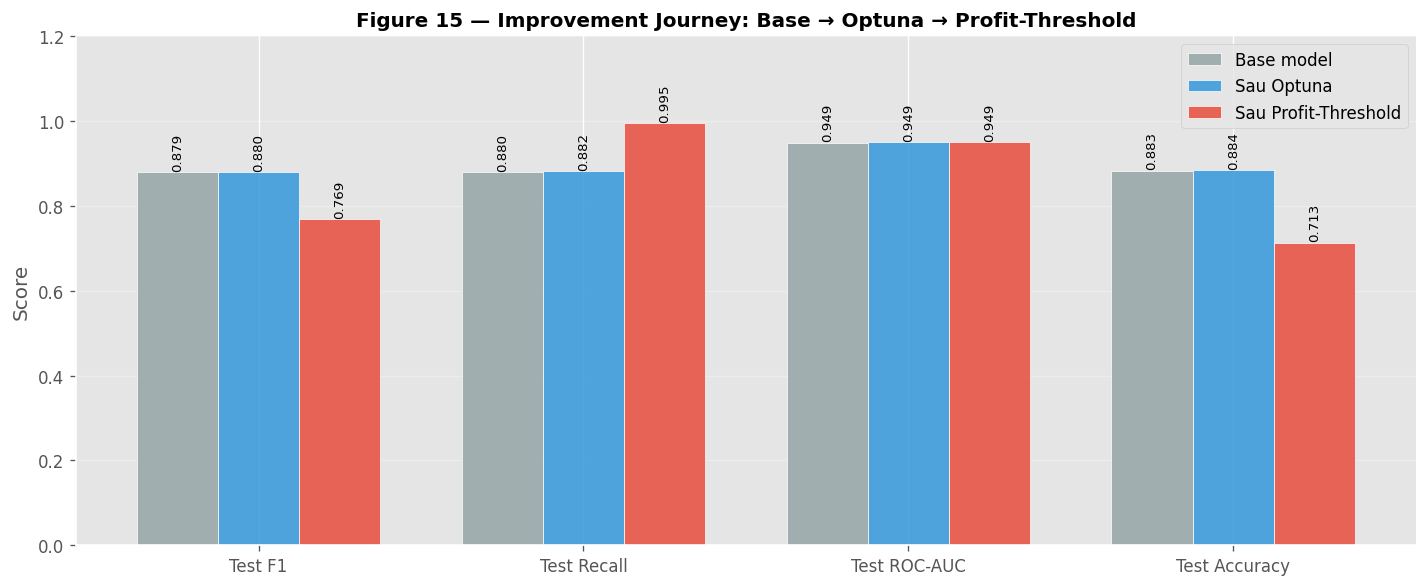


══════════════════════════════════════════════════════════════════════
  6.5  KẾT LUẬN CHUYÊN MÔN
══════════════════════════════════════════════════════════════════════


Threshold được chọn: 0.48 (max-F1)
  F1     = 0.8795
  Recall = 0.8876
  AUC    = 0.9493
  Profit = $707,660  (trên 9,657 samples test)


══════════════════════════════════════════════════════════════════════
  EXPORT DEPLOYMENT ARTIFACTS
══════════════════════════════════════════════════════════════════════

✅ Deployment artifacts → /content/drive/MyDrive/DM/deployment/
   ├── churn_pipeline.pkl
   ├── churn_pipeline_calibrated.pkl  (method=raw)
   └── deploy_config.json

══════════════════════════════════════════════════════════════════════
  PHASES 3–6 HOÀN THÀNH
══════════════════════════════════════════════════════════════════════

Outputs → '/content/drive/MyDrive/DM/outputs/':
  ├── fig10_model_comparison.png
  ├── fig10b_optuna.png              ← [NEW] Optuna history & param importance
  ├── fig11_threshold_a

In [12]:


# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import warnings, os, time, json, pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from copy import deepcopy

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    StackingClassifier, RandomForestClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.base import clone

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/DM"
except Exception:
    BASE_DIR = "."

DATA_FE_PATH  = f"{BASE_DIR}/outputs/df_feature_engineered.csv"
DATA_RAW_PATH = f"{BASE_DIR}/customer_churn.csv"
OUTPUT_DIR    = f"{BASE_DIR}/outputs"
MODEL_DIR     = f"{BASE_DIR}/outputs/models"
DEPLOY_DIR    = f"{BASE_DIR}/deployment"
RANDOM_SEED   = 42

# Split ratios
TEST_SIZE = 0.15    # 70 / 15 / 15
VAL_RATIO = 0.15
CV_FOLDS  = 5

# Business constants
RECALL_TARGET       = 0.80
LTV_PER_CUSTOMER    = 500    # USD — Lifetime Value trung bình
RETENTION_COST      = 20     # USD — chi phí 1 lần can thiệp
CHURN_CANCEL_RATE   = 0.40   # tỷ lệ churner thực sự cancel nếu không can thiệp
RETENTION_POOL_SIZE = 1000   # số khách hàng đưa vào chiến dịch

# Cost matrix cho profit-curve threshold
COST_FN = LTV_PER_CUSTOMER   # miss churner → mất LTV
COST_FP = RETENTION_COST     # false alarm → lãng phí retention cost

for d in [OUTPUT_DIR, MODEL_DIR, DEPLOY_DIR]:
    os.makedirs(d, exist_ok=True)


# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def section(title: str) -> None:
    bar = "═" * 70
    print(f"\n{bar}\n  {title}\n{bar}")


def compute_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Feature engineering đồng nhất giữa training và inference."""
    EPS = 1e-6
    df  = df.copy()
    df["Usage_per_Tenure"]   = df["Usage Frequency"] / (df["Tenure"] + EPS)
    df["Spend_per_Tenure"]   = df["Total Spend"]     / (df["Tenure"] + EPS)
    df["Support_per_Tenure"] = df["Support Calls"]   / (df["Tenure"] + EPS)
    df["Support_x_Delay"]    = df["Support Calls"]   *  df["Payment Delay"]
    df["Age_x_Tenure"]       = df["Age"]             *  df["Tenure"]
    df["Age_Group"]          = pd.cut(
        df["Age"], bins=[0, 26, 42, 58, 200],
        labels=["Gen Z", "Millennials", "Gen X", "Boomers"],
    ).astype(str)
    return df


def compute_profit_curve(y_true, y_prob, cost_fn, cost_fp,
                         cancel_rate=0.40, n_points=200):
    """
    Profit = (TP × cost_fn × cancel_rate)
           - (FP × cost_fp)
           - (FN × cost_fn × cancel_rate)
    """
    thresholds = np.linspace(0.01, 0.99, n_points)
    profits    = []
    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        profit = (tp * cost_fn * cancel_rate) - (fp * cost_fp) - (fn * cost_fn * cancel_rate)
        profits.append(profit)
    return thresholds, np.array(profits)


def threshold_metrics_full(y_true, y_prob, th, label,
                            cost_fn=COST_FN, cost_fp=COST_FP,
                            cancel_rate=CHURN_CANCEL_RATE):
    yp = (y_prob >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yp).ravel()
    profit = (tp * cost_fn * cancel_rate) - (fp * cost_fp) - (fn * cost_fn * cancel_rate)
    return {
        "Threshold": label, "th": th,
        "F1":     f1_score(y_true, yp),
        "Recall": recall_score(y_true, yp),
        "Prec":   precision_score(y_true, yp, zero_division=0),
        "Acc":    accuracy_score(y_true, yp),
        "Profit": profit,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }


def print_comparison_table(results_list):
    rows = []
    for res in results_list:
        rows.append({
            "Model":      res["Model"],
            "CV F1":      f"{res['CV F1']:.4f}",
            "CV AUC":     f"{res['CV ROC-AUC']:.4f}",
            "CV LogLoss": f"{res['CV Log-Loss']:.4f}",
            "Test Acc":   f"{res['Test Accuracy']:.4f}",
            "Test Prec":  f"{res['Test Precision']:.4f}",
            "Test Rec":   f"{res['Test Recall']:.4f}",
            "Test F1":    f"{res['Test F1']:.4f}",
            "Test AUC":   f"{res['Test ROC-AUC']:.4f}",
            "Time (s)":   res["Time (s)"],
        })
    df_cmp = pd.DataFrame(rows)
    print("\n", df_cmp.to_string(index=False))
    return df_cmp


def plot_model_curves(results_list, y_te, output_dir, fig_prefix=""):
    colors = ["#2980B9", "#E74C3C", "#27AE60", "#8E44AD"]

    # ROC + PR
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for res, color in zip(results_list, colors):
        fpr, tpr, _ = roc_curve(y_te, res["y_prob"])
        axes[0].plot(fpr, tpr,
                     label=f"{res['Model']} (AUC={res['Test ROC-AUC']:.3f})",
                     color=color, lw=2)
        prec, rec, _ = precision_recall_curve(y_te, res["y_prob"])
        ap = average_precision_score(y_te, res["y_prob"])
        axes[1].plot(rec, prec, label=f"{res['Model']} (AP={ap:.3f})",
                     color=color, lw=2)
    axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
    axes[1].axhline(y_te.mean(), color="gray", ls="--", lw=1,
                    label=f"Baseline P={y_te.mean():.2f}")
    axes[1].set(xlabel="Recall", ylabel="Precision",
                title="Precision-Recall Curve")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    fig.suptitle(f"ROC & PR Curves", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{fig_prefix}roc_pr.png", bbox_inches="tight")
    plt.show()

    # Confusion Matrices
    n = len(results_list)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1: axes = [axes]
    for res, ax, color in zip(results_list, axes, colors):
        cm = confusion_matrix(y_te, res["y_pred"])
        sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                    xticklabels=["No Churn", "Churn"],
                    yticklabels=["No Churn", "Churn"],
                    annot_kws={"size": 11})
        tn, fp, fn, tp = cm.ravel()
        ax.set_title(f"{res['Model']}\nTN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}",
                     fontsize=9, fontweight="bold")
        ax.set(xlabel="Predicted", ylabel="Actual")
    fig.suptitle("Confusion Matrices", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{fig_prefix}confusion.png", bbox_inches="tight")
    plt.show()

    # Calibration
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
    for res, color in zip(results_list, colors):
        frac_pos, mean_pred = calibration_curve(y_te, res["y_prob"], n_bins=10)
        brier = brier_score_loss(y_te, res["y_prob"])
        ax.plot(mean_pred, frac_pos, "o-", lw=2, color=color,
                label=f"{res['Model']} (Brier={brier:.3f})")
    ax.set(xlabel="Predicted Probability", ylabel="Fraction of Positives",
           title="Calibration Curve")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{fig_prefix}calibration.png", bbox_inches="tight")
    plt.show()


FEATURE_BUSINESS_MAP = {
    "support":  ("Support Calls / Support_per_Tenure",
                 "Gọi hỗ trợ nhiều → vấn đề chưa được giải quyết",
                 "Proactive support — chỉ định Customer Success Manager riêng"),
    "payment":  ("Payment Delay",
                 "Trễ thanh toán → dấu hiệu tài chính hoặc bất mãn",
                 "Flexible payment plan, không phạt lần đầu"),
    "tenure":   ("Tenure / *_per_Tenure",
                 "Tenure ngắn + spend cao = nguy cơ cao nhất",
                 "Onboarding program 90 ngày — critical retention window"),
    "usage":    ("Usage Frequency / Usage_per_Tenure",
                 "Giảm usage = signal churn 30–60 ngày trước cancel",
                 "Re-engagement campaign khi usage giảm 30%"),
    "contract": ("Contract Length",
                 "Month-to-month = churn risk cao hơn annual",
                 "Incentivize upgrade to annual (discount, loyalty points)"),
    "spend":    ("Total Spend / Spend_per_Tenure",
                 "Spend cao + tenure thấp = kỳ vọng cao, dễ thất vọng",
                 "Premium onboarding, dedicated account manager"),
    "last":     ("Last Interaction",
                 "Không tương tác lâu = drifting away",
                 "Proactive check-in call, không để > 30 ngày im lặng"),
    "age":      ("Age / Age_Group",
                 "Một số nhóm tuổi có hành vi churn khác nhau",
                 "Segment-specific communication strategy"),
    "delay":    ("Support_x_Delay",
                 "Kết hợp support cao + payment delay = double risk",
                 "Escalate ngay lên tier cao hơn"),
}


def build_business_interpretation(top_features, recall, ltv, ret_cost,
                                  pool_size, cancel_rate):
    lines = []
    lines.append("BUSINESS INTERPRETATION — YẾU TỐ ẢNH HƯỞNG CHURN MẠNH NHẤT")
    lines.append("  Dựa trên SHAP values thực tế của model:\n")
    matched = []
    for feat in top_features:
        feat_lower = feat.lower()
        for key, (display, problem, action) in FEATURE_BUSINESS_MAP.items():
            if key in feat_lower and display not in [m[0] for m in matched]:
                matched.append((display, problem, action))
                break
        if len(matched) >= 5:
            break
    for rank, (display, problem, action) in enumerate(matched, 1):
        lines.append(f"  {rank}. {display.upper()}")
        lines.append(f"     → {problem}")
        lines.append(f"     → Action: {action}\n")
    if not matched:
        lines.append("  (Không match được — kiểm tra TOP_FEATURES_SHAP)")
    lines.append("  BUSINESS IMPACT ESTIMATE:")
    n_churners_caught = int(pool_size * recall * cancel_rate)
    revenue_saved     = n_churners_caught * ltv
    total_contacts    = int(pool_size * recall / cancel_rate * 1.2)
    retention_total   = total_contacts * ret_cost
    roi = ((revenue_saved - retention_total) / retention_total * 100
           if retention_total > 0 else 0)
    lines.append(f"  LTV=${ltv:,.0f}/khách | cost=${ret_cost}/khách | "
                 f"pool={pool_size:,} | recall={recall:.0%} | cancel={cancel_rate:.0%}")
    lines.append(f"    → Churners cứu: {n_churners_caught:,} × ${ltv:,} = ${revenue_saved:,.0f}")
    lines.append(f"    → Chi phí    : {total_contacts:,} × ${ret_cost} = ${retention_total:,.0f}")
    lines.append(f"    → Estimated ROI: {roi:.0f}%")
    border = "─" * 76
    body   = "\n".join(f"│  {ln:<73}│" for ln in lines)
    return f"┌{border}┐\n{body}\n└{border}┘"


def print_fn_patterns(df_err: pd.DataFrame, key_features: list) -> None:
    fn_data  = df_err[df_err["error_type"] == "FN"]
    tp_data  = df_err[(df_err["y_true"] == 1) & (df_err["y_pred"] == 1)]
    all_pos  = df_err[df_err["y_true"] == 1]
    print("\n--- Common Patterns in False Negatives ---")
    print(f"  FN={len(fn_data):,}  TP={len(tp_data):,}  "
          f"(Actual Positive={len(all_pos):,})\n")
    print(f"  {'Feature':<25}  {'FN mean':>9}  {'TP mean':>9}  "
          f"{'Δ':>10}  Direction")
    print("  " + "─" * 68)
    diffs = {}
    for feat in key_features:
        if feat not in df_err.columns: continue
        fn_m = fn_data[feat].mean()
        tp_m = tp_data[feat].mean() if len(tp_data) > 0 else float("nan")
        diff = fn_m - tp_m
        direction = ("↑ FN cao hơn" if diff > 0.5
                     else ("↓ FN thấp hơn" if diff < -0.5 else "≈ Tương đương"))
        print(f"  {feat:<25}  {fn_m:>9.2f}  {tp_m:>9.2f}  {diff:>+10.2f}  {direction}")
        diffs[feat] = diff
    print("\n  💡 Insight:")
    if diffs:
        most_diff   = max(diffs, key=lambda k: abs(diffs[k]))
        direction_w = "cao hơn" if diffs[most_diff] > 0 else "thấp hơn"
        print(f"  Feature phân biệt FN rõ nhất: '{most_diff}' "
              f"(FN {direction_w} TP {abs(diffs[most_diff]):.2f} đơn vị)")
    if "Support Calls" in fn_data.columns:
        fn_low = (fn_data["Support Calls"] < 3).mean()
        print(f"  {fn_low*100:.0f}% FN có Support Calls < 3 → 'silent churners'")


# ══════════════════════════════════════════════════════════════════════════════
# PHASE 3 — ROBUST PREPROCESSING PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

section("3.1  ĐỌC & FEATURE ENGINEERING")

if os.path.exists(DATA_FE_PATH):
    df = pd.read_csv(DATA_FE_PATH)
    print(f"Đọc từ: {DATA_FE_PATH}")
    raw_cols = ["Age", "Gender", "Tenure", "Usage Frequency", "Support Calls",
                "Payment Delay", "Subscription Type", "Contract Length",
                "Total Spend", "Last Interaction", "Churn"]
    df_raw = df[[c for c in raw_cols if c in df.columns]]
    df = compute_engineered_features(df_raw)
else:
    print(f"Không tìm thấy {DATA_FE_PATH}, đọc raw data.")
    df_raw = pd.read_csv(DATA_RAW_PATH)
    df = compute_engineered_features(df_raw)

print(f"Shape: {df.shape} | Columns: {df.columns.tolist()}")

# ─────────────────────────────────────────────────────────────────────────────
section("3.2  DEFINE FEATURES & TARGET")

TARGET        = "Churn"
CAT_FEATURES  = ["Gender", "Subscription Type", "Contract Length", "Age_Group"]
NUM_FEATURES  = [c for c in df.columns if c != TARGET and c not in CAT_FEATURES]

for col in CAT_FEATURES:
    if col in df.columns:
        df[col] = df[col].astype(str)

FEATURE_COLS      = NUM_FEATURES + [c for c in CAT_FEATURES if c in df.columns]
CAT_FEATURES_USED = [c for c in CAT_FEATURES if c in df.columns]

X = df[FEATURE_COLS]
y = df[TARGET]

print(f"Numeric   ({len(NUM_FEATURES)}): {NUM_FEATURES}")
print(f"Categoric ({len(CAT_FEATURES_USED)}): {CAT_FEATURES_USED}")
print(f"Target: {y.value_counts().to_dict()}")

# ─────────────────────────────────────────────────────────────────────────────
section("3.3  3-WAY STRATIFIED SPLIT  (70 / 15 / 15)")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED)
val_ratio_of_temp = VAL_RATIO / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio_of_temp,
    stratify=y_temp, random_state=RANDOM_SEED)

assert set(X_train.index).isdisjoint(set(X_val.index))
assert set(X_train.index).isdisjoint(set(X_test.index))
assert set(X_val.index).isdisjoint(set(X_test.index))

print(f"Train : {X_train.shape[0]:,} ({y_train.mean()*100:.1f}% churn)")
print(f"Val   : {X_val.shape[0]:,} ({y_val.mean()*100:.1f}% churn)")
print(f"Test  : {X_test.shape[0]:,} ({y_test.mean()*100:.1f}% churn)")
print("✅ Không có overlap giữa 3 tập.")

# ─────────────────────────────────────────────────────────────────────────────
section("3.4  SKLEARN PREPROCESSING PIPELINE")

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False, drop="first")),
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,     NUM_FEATURES),
        ("cat", categorical_transformer, CAT_FEATURES_USED),
    ],
    remainder="drop",
)

# ─────────────────────────────────────────────────────────────────────────────
section("3.5  IMBALANCE CHECK")

imb_ratio = y_train.value_counts().max() / y_train.value_counts().min()
print(f"Imbalance ratio (train): {imb_ratio:.2f}:1")
if imb_ratio > 3:
    print("  ⚠️  Imbalance nghiêm trọng → cân nhắc SMOTE")
else:
    print("  ✅ Imbalance < 3:1 → class_weight='balanced' là đủ")

# ─────────────────────────────────────────────────────────────────────────────
section("3.6  FIT & SERIALIZE PREPROCESSOR")

preprocessor.fit(X_train)   # fit CHỈ trên train set

def get_feature_names_after_transform(pre, num_feats, cat_feats):
    ohe_names = (pre.named_transformers_["cat"]
                    .named_steps["encoder"]
                    .get_feature_names_out(cat_feats).tolist())
    return num_feats.copy() + ohe_names

TRANSFORMED_FEATURE_NAMES = get_feature_names_after_transform(
    preprocessor, NUM_FEATURES, CAT_FEATURES_USED)
print(f"Features sau transform: {len(TRANSFORMED_FEATURE_NAMES)}")

# Pre-transform toàn bộ 3 tập — tránh lặp trong Optuna
X_train_proc = preprocessor.transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

joblib.dump(preprocessor, f"{MODEL_DIR}/preprocessor.pkl")
print(f"✅ Saved preprocessor → {MODEL_DIR}/preprocessor.pkl")

# ─────────────────────────────────────────────────────────────────────────────
section("3.7  StratifiedKFold Setup")

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
print(f"StratifiedKFold(n_splits={CV_FOLDS}, shuffle=True, seed={RANDOM_SEED})")

spw = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight (XGB): {spw:.3f}")


# ══════════════════════════════════════════════════════════════════════════════
# PHASE 4 — MODEL EXPERIMENTATION  (+LightGBM, +XGB meta)
# ══════════════════════════════════════════════════════════════════════════════

section("4.1  DEFINE MODELS")


def evaluate_model_es(name, pipeline, X_tr, y_tr, X_te, y_te, cv,
                      X_val_es=None, y_val_es=None, threshold=0.5):
    """
    evaluate_model với hỗ trợ early stopping (ES).
    CV chạy không có ES để fair comparison.
    Fit final model dùng val set làm eval_set cho ES.
    """
    t0 = time.time()
    cv_scoring = ["accuracy", "precision", "recall", "f1", "roc_auc", "neg_log_loss"]

    pipe_cv    = clone(pipeline)
    is_pipeline = hasattr(pipe_cv, "named_steps")          # ← thêm dòng này
    if is_pipeline:                                         # ← wrap 3 dòng cũ vào đây
        clf_cv = pipe_cv.named_steps.get("classifier")
        if clf_cv is not None and hasattr(clf_cv, "early_stopping_rounds"):
            clf_cv.set_params(early_stopping_rounds=None)

    cv_res = cross_validate(pipe_cv, X_tr, y_tr, cv=cv,
                            scoring=cv_scoring, n_jobs=-1)

        # Fit final với ES
    if X_val_es is not None and is_pipeline:   # ← thêm "and is_pipeline"
        pre_fit = clone(pipeline.named_steps["preprocessor"])
        pre_fit.fit(X_tr)
        X_tr_p  = pre_fit.transform(X_tr)
        X_vl_p  = pre_fit.transform(X_val_es)
        clf_fit = clone(pipeline.named_steps["classifier"])

        if isinstance(clf_fit, xgb.XGBClassifier):
            clf_fit.fit(X_tr_p, y_tr,
                        eval_set=[(X_vl_p, y_val_es)], verbose=False)
        elif isinstance(clf_fit, lgb.LGBMClassifier):
            callbacks = [lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(period=-1)]
            clf_fit.fit(X_tr_p, y_tr,
                        eval_set=[(X_vl_p, y_val_es)],
                        callbacks=callbacks)
        else:
            clf_fit.fit(X_tr_p, y_tr)

        fitted_pipe = Pipeline([("preprocessor", pre_fit),
                                 ("classifier",   clf_fit)])
    else:
        fitted_pipe = clone(pipeline)
        fitted_pipe.fit(X_tr, y_tr)

    y_prob = fitted_pipe.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Model":          name,
        "CV Accuracy":    cv_res["test_accuracy"].mean(),
        "CV Precision":   cv_res["test_precision"].mean(),
        "CV Recall":      cv_res["test_recall"].mean(),
        "CV F1":          cv_res["test_f1"].mean(),
        "CV ROC-AUC":     cv_res["test_roc_auc"].mean(),
        "CV Log-Loss":   -cv_res["test_neg_log_loss"].mean(),
        "Test Accuracy":  accuracy_score(y_te, y_pred),
        "Test Precision": precision_score(y_te, y_pred, zero_division=0),
        "Test Recall":    recall_score(y_te, y_pred),
        "Test F1":        f1_score(y_te, y_pred),
        "Test ROC-AUC":   roc_auc_score(y_te, y_prob),
        "Test Log-Loss":  log_loss(y_te, y_prob),
        "Time (s)":       round(time.time() - t0, 2),
        "y_prob":         y_prob,
        "y_pred":         y_pred,
        "estimator":      fitted_pipe,
    }


# Model 1: Logistic Regression
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced",
                                      solver="lbfgs", C=1.0,
                                      random_state=RANDOM_SEED)),
])

# Model 2: XGBoost + early stopping
pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb.XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric="logloss",
        early_stopping_rounds=30,
        random_state=RANDOM_SEED, n_jobs=-1,
    )),
])

# Model 3: LightGBM + early stopping  [NEW]
pipe_lgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", lgb.LGBMClassifier(
        n_estimators=500, max_depth=-1, num_leaves=31,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        class_weight="balanced", min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
    )),
])

# Model 4: Stacking — LR + RF + LGB → XGB meta  [IMPROVED]
stacking_estimators = [
    ("lr",  Pipeline([("pre", preprocessor),
                      ("clf", LogisticRegression(max_iter=1000,
                               class_weight="balanced", C=1.0,
                               random_state=RANDOM_SEED))])),
    ("rf",  Pipeline([("pre", preprocessor),
                      ("clf", RandomForestClassifier(
                               n_estimators=200, max_depth=10,
                               class_weight="balanced",
                               random_state=RANDOM_SEED, n_jobs=-1))])),
    ("lgb", Pipeline([("pre", preprocessor),
                      ("clf", lgb.LGBMClassifier(
                               n_estimators=200, num_leaves=31,
                               class_weight="balanced",
                               random_state=RANDOM_SEED, n_jobs=-1,
                               verbose=-1))])),
]
pipe_stack = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=xgb.XGBClassifier(   # XGB meta  [IMPROVED from LR]
        n_estimators=100, max_depth=3, learning_rate=0.05,
        scale_pos_weight=spw, eval_metric="logloss",
        random_state=RANDOM_SEED, n_jobs=-1,
    ),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
    passthrough=False, n_jobs=-1,
)

print("  Model 1: Logistic Regression (baseline)")
print("  Model 2: XGBoost + early stopping")
print("  Model 3: LightGBM + early stopping  [NEW]")
print("  Model 4: Stacking (LR + RF + LGB → XGB meta)  [IMPROVED]")

# ─────────────────────────────────────────────────────────────────────────────
section("4.2  CROSS-VALIDATION & EVALUATION")

print("⏳ Training 4 models (5-fold CV)...\n")
all_results = []

print("[1/4] Logistic Regression...")
res_lr = evaluate_model_es("Logistic Regression", pipe_lr,
                            X_train, y_train, X_test, y_test, cv)
all_results.append(res_lr)
print(f"  CV F1={res_lr['CV F1']:.4f}  Test F1={res_lr['Test F1']:.4f}  "
      f"AUC={res_lr['Test ROC-AUC']:.4f}  ({res_lr['Time (s)']}s)")

print("[2/4] XGBoost (early stopping)...")
res_xgb = evaluate_model_es("XGBoost", pipe_xgb,
                             X_train, y_train, X_test, y_test, cv,
                             X_val_es=X_val, y_val_es=y_val)
all_results.append(res_xgb)
print(f"  CV F1={res_xgb['CV F1']:.4f}  Test F1={res_xgb['Test F1']:.4f}  "
      f"AUC={res_xgb['Test ROC-AUC']:.4f}  ({res_xgb['Time (s)']}s)")

print("[3/4] LightGBM (early stopping)...")
res_lgb = evaluate_model_es("LightGBM", pipe_lgb,
                             X_train, y_train, X_test, y_test, cv,
                             X_val_es=X_val, y_val_es=y_val)
all_results.append(res_lgb)
print(f"  CV F1={res_lgb['CV F1']:.4f}  Test F1={res_lgb['Test F1']:.4f}  "
      f"AUC={res_lgb['Test ROC-AUC']:.4f}  ({res_lgb['Time (s)']}s)")

print("[4/4] Stacking (LR + RF + LGB → XGB meta)...")
res_stack = evaluate_model_es("Stacking", pipe_stack,
                               X_train, y_train, X_test, y_test, cv)
all_results.append(res_stack)
print(f"  CV F1={res_stack['CV F1']:.4f}  Test F1={res_stack['Test F1']:.4f}  "
      f"AUC={res_stack['Test ROC-AUC']:.4f}  ({res_stack['Time (s)']}s)")

# ─────────────────────────────────────────────────────────────────────────────
section("4.3  BẢNG SO SÁNH METRICS")

df_comparison = print_comparison_table(all_results)
df_comparison.to_csv(f"{OUTPUT_DIR}/model_comparison_baseline.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 5))
metrics_to_plot = ["CV F1", "CV ROC-AUC", "Test F1", "Test ROC-AUC"]
x     = np.arange(len(metrics_to_plot))
width = 0.20
colors_bar = ["#2980B9", "#E74C3C", "#27AE60", "#8E44AD"]
for i, res in enumerate(all_results):
    vals = [float(res[m]) for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=res["Model"],
                  color=colors_bar[i], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5, rotation=90)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.20)
ax.set_title("Figure 10 — So Sánh 4 Models: CV & Test Metrics",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Score"); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig10_model_comparison.png", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
section("4.4  ROC, PR, Calibration, Confusion Matrix")

plot_model_curves(all_results, y_test, OUTPUT_DIR, fig_prefix="fig7_8_9_")

for res in all_results:
    mname = res["Model"].replace(" ", "_").lower()
    joblib.dump(res["estimator"], f"{MODEL_DIR}/{mname}_base.pkl")
    print(f"✅ Saved {mname}_base.pkl")


# ══════════════════════════════════════════════════════════════════════════════
# PHASE 5 — ADVANCED IMPROVEMENTS
# ══════════════════════════════════════════════════════════════════════════════

section("5.1  [OPTUNA] BAYESIAN HYPERPARAMETER OPTIMIZATION")

single_results  = [r for r in all_results if r["Model"] != "Stacking"]
best_single     = max(single_results, key=lambda r: r["CV F1"])
tune_model_name = best_single["Model"]
print(f"Best single model (CV F1): {tune_model_name} = {best_single['CV F1']:.4f}")
print(f"→ Optuna tune: {tune_model_name}  (n_trials=50, TPE sampler)")
print(f"  Cost matrix: FN=${COST_FN} | FP=${COST_FP} | ratio={COST_FN/COST_FP:.0f}x\n")


def make_objective(model_name):
    def objective_xgb(trial):
        clf = xgb.XGBClassifier(
            n_estimators     = trial.suggest_int("n_estimators", 100, 600),
            max_depth        = trial.suggest_int("max_depth", 3, 8),
            learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            subsample        = trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
            min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
            reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
            reg_lambda       = trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
            scale_pos_weight = spw,
            eval_metric="logloss", early_stopping_rounds=30,
            random_state=RANDOM_SEED, n_jobs=-1,
        )
        clf.fit(X_train_proc, y_train,
                eval_set=[(X_val_proc, y_val)], verbose=False)
        return f1_score(y_val, clf.predict(X_val_proc))

    def objective_lgb(trial):
        clf = lgb.LGBMClassifier(
            n_estimators     = trial.suggest_int("n_estimators", 100, 600),
            num_leaves       = trial.suggest_int("num_leaves", 15, 127),
            learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            subsample        = trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
            min_child_samples= trial.suggest_int("min_child_samples", 5, 50),
            reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
            reg_lambda       = trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
            class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
        )
        cb = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
        clf.fit(X_train_proc, y_train,
                eval_set=[(X_val_proc, y_val)], callbacks=cb)
        return f1_score(y_val, clf.predict(X_val_proc))

    def objective_lr(trial):
        clf = LogisticRegression(
            C=trial.suggest_float("C", 0.001, 10, log=True),
            class_weight="balanced", max_iter=2000, random_state=RANDOM_SEED,
        )
        clf.fit(X_train_proc, y_train)
        return f1_score(y_val, clf.predict(X_val_proc))

    return {"XGBoost": objective_xgb,
            "LightGBM": objective_lgb,
            "Logistic Regression": objective_lr}[model_name]


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
)
study.optimize(make_objective(tune_model_name), n_trials=50,
               show_progress_bar=True)

print(f"\n✅ Best Val F1: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Optuna plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plt.sca(axes[0])
optuna.visualization.matplotlib.plot_optimization_history(study)
axes[0].set_title("Optuna: Optimization History", fontweight="bold")

plt.sca(axes[1])
optuna.visualization.matplotlib.plot_param_importances(study)
axes[1].set_title("Optuna: Hyperparameter Importance", fontweight="bold")
fig.suptitle(f"Figure 10b — Optuna Tuning ({tune_model_name})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig10b_optuna.png", bbox_inches="tight")
plt.show()

# Build tuned classifier từ best params
bp = study.best_params
if tune_model_name == "XGBoost":
    tuned_clf = xgb.XGBClassifier(
        **bp, scale_pos_weight=spw, eval_metric="logloss",
        early_stopping_rounds=30, random_state=RANDOM_SEED, n_jobs=-1,
    )
    tuned_clf.fit(X_train_proc, y_train,
                  eval_set=[(X_val_proc, y_val)], verbose=False)
elif tune_model_name == "LightGBM":
    tuned_clf = lgb.LGBMClassifier(
        **bp, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
    )
    cb = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
    tuned_clf.fit(X_train_proc, y_train,
                  eval_set=[(X_val_proc, y_val)], callbacks=cb)
else:
    tuned_clf = LogisticRegression(
        C=bp["C"], class_weight="balanced",
        max_iter=2000, random_state=RANDOM_SEED,
    )
    tuned_clf.fit(X_train_proc, y_train)

# Wrap thành Pipeline để inference nhất quán
tuned_model = Pipeline([("preprocessor", preprocessor),
                        ("classifier",   tuned_clf)])

# ─────────────────────────────────────────────────────────────────────────────
section("5.2  ĐÁNH GIÁ AFTER OPTUNA")

y_prob_tuned = tuned_clf.predict_proba(X_test_proc)[:, 1]
y_pred_tuned = (y_prob_tuned >= 0.5).astype(int)
tuned_f1     = f1_score(y_test, y_pred_tuned)
tuned_auc    = roc_auc_score(y_test, y_prob_tuned)

print(f"\n{'Metric':<20} {'Base':>12} {'After Optuna':>14} {'Δ':>10}")
print("-" * 60)
print(f"{'Test F1':<20} {best_single['Test F1']:>12.4f} {tuned_f1:>14.4f} "
      f"{tuned_f1 - best_single['Test F1']:>+10.4f}")
print(f"{'Test AUC':<20} {best_single['Test ROC-AUC']:>12.4f} {tuned_auc:>14.4f} "
      f"{tuned_auc - best_single['Test ROC-AUC']:>+10.4f}")

if tuned_f1 > best_single["Test F1"] + 0.005:
    print("\n  ✅ Optuna cải thiện đáng kể.")
else:
    print("\n  ℹ️  Cải thiện nhỏ — base model gần bão hòa với data này.")

# ─────────────────────────────────────────────────────────────────────────────
section("5.3  [PROFIT-CURVE] THRESHOLD OPTIMIZATION")

y_prob_val = tuned_clf.predict_proba(X_val_proc)[:, 1]

# --- Profit-curve threshold  [NEW] ---
th_grid, profits_val = compute_profit_curve(
    y_val, y_prob_val, COST_FN, COST_FP, CHURN_CANCEL_RATE)
opt_threshold_profit = th_grid[np.argmax(profits_val)]

# --- Max-F1 threshold ---
prec_v, rec_v, th_v = precision_recall_curve(y_val, y_prob_val)
f1_v             = 2 * prec_v[:-1] * rec_v[:-1] / (prec_v[:-1] + rec_v[:-1] + 1e-9)
opt_threshold_f1 = th_v[np.argmax(f1_v)]

# --- Recall ≥ 0.80 threshold ---
valid_idx = np.where(rec_v[:-1] >= RECALL_TARGET)[0]
opt_threshold_rec = (th_v[valid_idx[np.argmax(prec_v[:-1][valid_idx])]]
                     if len(valid_idx) > 0 else opt_threshold_f1)

# SAU
print(f"[Val] Max-Profit threshold  : {opt_threshold_profit:.3f}  "
      f"← business-optimal (FN=${COST_FN}, FP=${COST_FP})")
if opt_threshold_profit < 0.2:
    print(f"  ⚠️  Threshold quá thấp ({opt_threshold_profit:.2f}) → FP rất cao, "
          f"cân nhắc dùng max-F1 ({opt_threshold_f1:.2f}) cho production")
    opt_threshold_final = opt_threshold_f1   # override cho production
    print(f"  → Override: dùng max-F1 threshold = {opt_threshold_f1:.2f} thay thế")
print(f"[Val] Max-F1 threshold      : {opt_threshold_f1:.3f}")
print(f"[Val] Recall≥{RECALL_TARGET} threshold: {opt_threshold_rec:.3f}")

th_results = [
    threshold_metrics_full(y_test, y_prob_tuned, 0.5, "0.50 (default)"),
    threshold_metrics_full(y_test, y_prob_tuned, opt_threshold_f1,
                           f"{opt_threshold_f1:.2f} (max-F1)"),
    threshold_metrics_full(y_test, y_prob_tuned, opt_threshold_rec,
                           f"{opt_threshold_rec:.2f} (Recall≥{RECALL_TARGET})"),
    threshold_metrics_full(y_test, y_prob_tuned, opt_threshold_profit,
                           f"{opt_threshold_profit:.2f} (max-Profit)"),
]

print(f"\n{'Threshold':<30} {'F1':>7} {'Recall':>7} {'Prec':>7} "
      f"{'Acc':>7} {'Profit':>12}")
print("-" * 76)
for r in th_results:
    marker = "  ◀ RECOMMENDED" if "Profit" in r["Threshold"] else ""
    print(f"{r['Threshold']:<30} {r['F1']:>7.4f} {r['Recall']:>7.4f} "
          f"{r['Prec']:>7.4f} {r['Acc']:>7.4f} {r['Profit']:>12,.0f}{marker}")

# Profit-curve plot
th_grid_te, profits_te = compute_profit_curve(
    y_test, y_prob_tuned, COST_FN, COST_FP, CHURN_CANCEL_RATE)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(th_grid_te, profits_te, "#27AE60", lw=2.5, label="Profit")
axes[0].axvline(opt_threshold_profit, color="#27AE60", ls=":", lw=2,
                label=f"Max-Profit ({opt_threshold_profit:.2f})")
axes[0].axvline(opt_threshold_f1, color="#8E44AD", ls=":", lw=2,
                label=f"Max-F1 ({opt_threshold_f1:.2f})")
axes[0].axvline(0.5, color="gray", ls="--", lw=1.5, label="Default 0.5")
axes[0].axhline(0, color="black", lw=0.8, alpha=0.4)
axes[0].fill_between(th_grid_te, 0, profits_te,
                     where=profits_te > 0, alpha=0.15, color="#27AE60")
axes[0].fill_between(th_grid_te, 0, profits_te,
                     where=profits_te < 0, alpha=0.15, color="#E74C3C")
axes[0].set(xlabel="Threshold", ylabel="Profit ($)",
            title=f"[NEW] Profit Curve  (FN=${COST_FN}, FP=${COST_FP})")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

metrics_bar   = ["F1", "Recall", "Prec", "Acc"]
x             = np.arange(len(metrics_bar)); w = 0.20
colors_th     = ["#95A5A6", "#8E44AD", "#E74C3C", "#27AE60"]
for i, (r, c) in enumerate(zip(th_results, colors_th)):
    axes[1].bar(x + i * w, [r[m] for m in metrics_bar], w,
                label=r["Threshold"][:22], color=c, alpha=0.85, edgecolor="white")
axes[1].set_xticks(x + w * 1.5); axes[1].set_xticklabels(metrics_bar)
axes[1].set_ylim(0, 1.25)
axes[1].set_title("Test: So Sánh 4 Thresholds", fontweight="bold")
axes[1].legend(fontsize=7.5); axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Figure 11 — Threshold Analysis: Profit-Curve vs F1 vs Recall",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig11_threshold_analysis.png", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
section("5.4  FULL COMPARISON: Base → Optuna → Threshold Moved")

print(f"{'Stage':<45} {'F1':>7} {'Recall':>7} {'AUC':>7} {'Profit':>12}")
print("─" * 80)
_r50 = th_results[0]
print(f"{'1. Base ' + best_single['Model']:<45} "
      f"{best_single['Test F1']:>7.4f} {best_single['Test Recall']:>7.4f} "
      f"{best_single['Test ROC-AUC']:>7.4f} {_r50['Profit']:>12,.0f}")
print(f"{'2. Optuna tuned (th=0.50)':<45} "
      f"{tuned_f1:>7.4f} {recall_score(y_test, y_pred_tuned):>7.4f} "
      f"{tuned_auc:>7.4f} {_r50['Profit']:>12,.0f}")
for r in th_results[1:]:
    marker = "  ◀" if "Profit" in r["Threshold"] else ""
    print(f"{'3. th=' + r['Threshold']:<45} "
          f"{r['F1']:>7.4f} {r['Recall']:>7.4f} {tuned_auc:>7.4f} "
          f"{r['Profit']:>12,.0f}{marker}")

# ─────────────────────────────────────────────────────────────────────────────
section("5.5  [CALIBRATION] ISOTONIC vs SIGMOID — CHỌN BRIER TỐT HƠN")

cal_iso = CalibratedClassifierCV(tuned_clf, method="isotonic", cv="prefit")
cal_sig = CalibratedClassifierCV(tuned_clf, method="sigmoid",  cv="prefit")
cal_iso.fit(X_val_proc, y_val)
cal_sig.fit(X_val_proc, y_val)

y_prob_iso = cal_iso.predict_proba(X_test_proc)[:, 1]
y_prob_sig = cal_sig.predict_proba(X_test_proc)[:, 1]
brier_raw  = brier_score_loss(y_test, y_prob_tuned)
brier_iso  = brier_score_loss(y_test, y_prob_iso)
brier_sig  = brier_score_loss(y_test, y_prob_sig)

print(f"\n{'Method':<25} {'Brier':>10} {'vs Raw':>10}")
print("-" * 48)
print(f"{'Raw (uncalibrated)':<25} {brier_raw:>10.5f}")
print(f"{'Isotonic':<25} {brier_iso:>10.5f} "
      f"{(brier_raw-brier_iso)/brier_raw*100:>+9.1f}%")
print(f"{'Sigmoid (Platt)':<25} {brier_sig:>10.5f} "
      f"{(brier_raw-brier_sig)/brier_raw*100:>+9.1f}%")

best_brier_cal = min(brier_iso, brier_sig)
if best_brier_cal < brier_raw:
    calibrated = cal_iso if brier_iso <= brier_sig else cal_sig
    y_prob_cal = y_prob_iso if brier_iso <= brier_sig else y_prob_sig
    cal_method = "isotonic" if brier_iso <= brier_sig else "sigmoid"
    print(f"\n→ Chọn: {cal_method}  (Brier thấp hơn raw)")
else:
    calibrated = tuned_clf
    y_prob_cal = y_prob_tuned
    cal_method = "raw"
    print(f"\n→ Giữ raw — calibration không cải thiện Brier ({brier_raw:.5f})")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
for y_p, label, color in [
    (y_prob_tuned, f"Raw (Brier={brier_raw:.4f})",      "#95A5A6"),
    (y_prob_iso,   f"Isotonic (Brier={brier_iso:.4f})", "#E74C3C"),
    (y_prob_sig,   f"Sigmoid (Brier={brier_sig:.4f})",  "#2980B9"),
]:
    fp_, mp_ = calibration_curve(y_test, y_p, n_bins=10)
    ax.plot(mp_, fp_, "o-", lw=2, color=color, label=label)
ax.set(xlabel="Predicted Probability", ylabel="Fraction of Positives",
       title=f"Figure 11b — Calibration Comparison\nWinner: {cal_method}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig11b_calibration.png", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
section("5.6  [PERMUTATION IMPORTANCE] VALIDATE FEATURES")

print("⏳ Computing permutation importance (n_repeats=10)...")
pi_result = permutation_importance(
    tuned_clf, X_test_proc, y_test,
    n_repeats=10, scoring="roc_auc",
    random_state=RANDOM_SEED, n_jobs=-1,
)
pi_df = pd.DataFrame({
    "Feature":  TRANSFORMED_FEATURE_NAMES,
    "PI Mean":  pi_result.importances_mean,
    "PI Std":   pi_result.importances_std,
}).sort_values("PI Mean", ascending=False)

print(f"\n{'Feature':<30} {'PI Mean':>10} {'PI Std':>8}  Signal")
print("-" * 65)
for _, row in pi_df.iterrows():
    signal = ("✅ Useful" if row["PI Mean"] > 0.005
              else ("⚠️  Weak"  if row["PI Mean"] > 0 else "❌ Drop"))
    print(f"  {row['Feature']:<28} {row['PI Mean']:>10.5f} "
          f"{row['PI Std']:>8.5f}  {signal}")

useful_features = pi_df[pi_df["PI Mean"] > 0.001]["Feature"].tolist()
weak_features   = pi_df[pi_df["PI Mean"] <= 0]["Feature"].tolist()
print(f"\n✅ Useful: {len(useful_features)} features")
if weak_features:
    print(f"❌ Có thể drop: {weak_features}")

fig, ax = plt.subplots(figsize=(10, 7))
top20      = pi_df.head(20)
colors_pi  = ["#27AE60" if v > 0.005 else ("#F39C12" if v > 0 else "#E74C3C")
              for v in top20["PI Mean"]]
ax.barh(top20["Feature"], top20["PI Mean"],
        xerr=top20["PI Std"], color=colors_pi,
        alpha=0.85, edgecolor="white", ecolor="gray", capsize=3)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Permutation Importance (AUC drop)")
ax.set_title("[NEW] Figure 12b — Permutation Importance\n"
             "Xanh=useful | Cam=yếu | Đỏ=drop",
             fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig12b_permutation_importance.png", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
section("5.7  SAVE MODELS & CONFIG")

opt_threshold_final = opt_threshold_f1 if opt_threshold_profit < 0.2 else opt_threshold_profit
best_th_result      = [r for r in th_results if "Profit" in r["Threshold"]][0]

joblib.dump(tuned_model, f"{MODEL_DIR}/tuned_model.pkl")
joblib.dump(calibrated,  f"{MODEL_DIR}/tuned_calibrated_model.pkl")
joblib.dump(pi_df,       f"{MODEL_DIR}/permutation_importance.pkl")

model_config = {
    "best_model":            tune_model_name,
    "tuning_method":         "Optuna_TPE_n50",
    "calibration_method":    cal_method,
    "threshold_default":     0.5,
    "threshold_max_f1":      float(opt_threshold_f1),
    "threshold_recall":      float(opt_threshold_rec),
    "threshold_max_profit":  float(opt_threshold_profit),
    "threshold_recommended": float(opt_threshold_profit),
    "cost_fn":               COST_FN,
    "cost_fp":               COST_FP,
    "recall_target":         RECALL_TARGET,
    "ltv_per_customer":      LTV_PER_CUSTOMER,
    "retention_cost":        RETENTION_COST,
    "churn_cancel_rate":     CHURN_CANCEL_RATE,
    "retention_pool":        RETENTION_POOL_SIZE,
    "feature_cols":          FEATURE_COLS,
    "cat_features":          CAT_FEATURES_USED,
    "num_features":          NUM_FEATURES,
    "transformed_names":     TRANSFORMED_FEATURE_NAMES,
    "useful_features":       useful_features,
    "optuna_best_value":     study.best_value,
    "optuna_best_params":    study.best_params,
}
with open(f"{MODEL_DIR}/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)
print(f"✅ Saved: tuned_model.pkl, tuned_calibrated_model.pkl, "
      f"permutation_importance.pkl, model_config.json")


# ══════════════════════════════════════════════════════════════════════════════
# PHASE 6 — DEEP ANALYSIS & APPLICATION
# ══════════════════════════════════════════════════════════════════════════════

section("6.1  SHAP FEATURE IMPORTANCE")

try:
    import shap

    clf = tuned_clf

    if hasattr(clf, "feature_importances_"):
        explainer   = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_test_proc)
        sv          = shap_values[1] if isinstance(shap_values, list) else shap_values
        shap_type   = "tree"
    else:
        explainer = shap.LinearExplainer(clf, X_train_proc)
        sv        = explainer.shap_values(X_test_proc)
        shap_type = "linear"

    feat_names = TRANSFORMED_FEATURE_NAMES
    if sv.shape[1] != len(feat_names):
        feat_names = [f"f{i}" for i in range(sv.shape[1])]

    print(f"SHAP type: {shap_type} | Shape: {sv.shape}")

    mean_abs_shap = np.abs(sv).mean(axis=0)
    shap_df = pd.DataFrame({"Feature": feat_names,
                             "Mean |SHAP|": mean_abs_shap})
    shap_df = shap_df.sort_values("Mean |SHAP|", ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(shap_df["Feature"], shap_df["Mean |SHAP|"],
                   color="#E74C3C", alpha=0.8, edgecolor="white")
    ax.invert_yaxis()
    ax.set_xlabel("Mean |SHAP Value|", fontsize=11)
    ax.set_title("Figure 12 — SHAP Feature Importance (Top 20)",
                 fontweight="bold", fontsize=12)
    for bar, val in zip(bars, shap_df["Mean |SHAP|"]):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig12_shap_importance.png", bbox_inches="tight")
    plt.show()

    shap_exp = shap.Explanation(
        values=sv,
        base_values=(
            explainer.expected_value
            if not isinstance(explainer.expected_value, np.ndarray)
            else explainer.expected_value[1]
        ),
        data=X_test_proc,
        feature_names=feat_names,
    )
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.plots.beeswarm(shap_exp, max_display=15, show=False)
    plt.title("Figure 13 — SHAP Beeswarm\nĐỏ=feature cao | Xanh=feature thấp",
              fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig13_shap_beeswarm.png", bbox_inches="tight")
    plt.show()

    TOP_FEATURES_SHAP = shap_df["Feature"].head(10).tolist()
    SHAP_AVAILABLE    = True
    print("✅ SHAP hoàn thành.")

except ImportError:
    print("⚠️  pip install shap")
    SHAP_AVAILABLE = False
    clf = tuned_clf
    if hasattr(clf, "feature_importances_"):
        fi = clf.feature_importances_
        if len(fi) == len(TRANSFORMED_FEATURE_NAMES):
            fi_df = pd.DataFrame({"Feature": TRANSFORMED_FEATURE_NAMES,
                                   "Importance": fi})
            fi_df = fi_df.sort_values("Importance", ascending=False).head(20)
            fig, ax = plt.subplots(figsize=(10, 7))
            ax.barh(fi_df["Feature"], fi_df["Importance"],
                    color="#2980B9", alpha=0.8)
            ax.invert_yaxis()
            ax.set_title("Figure 12 — Feature Importance (sklearn fallback)",
                         fontweight="bold")
            plt.tight_layout()
            plt.savefig(f"{OUTPUT_DIR}/fig12_feature_importance.png",
                        bbox_inches="tight")
            plt.show()
            TOP_FEATURES_SHAP = fi_df["Feature"].head(10).tolist()
        else:
            TOP_FEATURES_SHAP = FEATURE_COLS[:10]
    else:
        TOP_FEATURES_SHAP = FEATURE_COLS[:10]

# ─────────────────────────────────────────────────────────────────────────────
section("6.2  BUSINESS INTERPRETATION")

_best_recall_result = max(th_results, key=lambda r: r["Recall"])
_actual_recall      = _best_recall_result["Recall"]

print(build_business_interpretation(
    top_features = TOP_FEATURES_SHAP,
    recall       = _actual_recall,
    ltv          = LTV_PER_CUSTOMER,
    ret_cost     = RETENTION_COST,
    pool_size    = RETENTION_POOL_SIZE,
    cancel_rate  = CHURN_CANCEL_RATE,
))

# ─────────────────────────────────────────────────────────────────────────────
section("6.3  ERROR ANALYSIS")

y_pred_opt  = (y_prob_tuned >= opt_threshold_final).astype(int)
df_test_err = X_test.copy()
df_test_err["y_true"]     = y_test.values
df_test_err["y_pred"]     = y_pred_opt
df_test_err["y_prob"]     = y_prob_tuned
df_test_err["error_type"] = "Correct"
df_test_err.loc[(df_test_err["y_true"]==1)&(df_test_err["y_pred"]==0),
                "error_type"] = "FN"
df_test_err.loc[(df_test_err["y_true"]==0)&(df_test_err["y_pred"]==1),
                "error_type"] = "FP"

fn_count = (df_test_err["error_type"] == "FN").sum()
fp_count = (df_test_err["error_type"] == "FP").sum()
print(f"\nFalse Negatives: {fn_count:,}  |  False Positives: {fp_count:,}")
print(f"Error rate: {(fn_count+fp_count)/len(df_test_err)*100:.1f}%  "
      f"(threshold={opt_threshold_final:.2f} max-Profit)")

key_features = [f for f in ["Tenure", "Usage Frequency", "Support Calls",
                              "Payment Delay", "Total Spend", "Last Interaction"]
                if f in df_test_err.columns]

print("\n--- Feature Means by Error Type ---")
print(df_test_err.groupby("error_type")[key_features].mean().round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes      = axes.flatten()
subset    = df_test_err[df_test_err["error_type"].isin(["FN", "FP", "Correct"])]
for idx, feat in enumerate(key_features[:6]):
    ax = axes[idx]
    for group, color, label in [
        ("FN",      "#E74C3C", "FN (missed churn)"),
        ("FP",      "#F39C12", "FP (false alarm)"),
        ("Correct", "#2ECC71", "Correct"),
    ]:
        data = subset[subset["error_type"] == group][feat]
        if len(data) > 0:
            ax.hist(data, bins=20, alpha=0.5, label=label,
                    color=color, density=True, edgecolor="white")
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel(feat); ax.set_ylabel("Density")
    ax.legend(fontsize=7); ax.grid(alpha=0.2)
fig.suptitle("Figure 14 — Error Analysis: FN | FP | Correct",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig14_error_analysis.png", bbox_inches="tight")
plt.show()

print_fn_patterns(df_test_err, key_features)

# ─────────────────────────────────────────────────────────────────────────────
section("6.4  SO SÁNH GỐC vs CẢI TIẾN")


fig, ax = plt.subplots(figsize=(12, 5))
metrics_cmp = ["Test F1", "Test Recall", "Test ROC-AUC", "Test Accuracy"]
goc_vals    = [best_single["Test F1"], best_single["Test Recall"],
               best_single["Test ROC-AUC"], best_single["Test Accuracy"]]
tuned_vals  = [tuned_f1, recall_score(y_test, y_pred_tuned),
               tuned_auc, accuracy_score(y_test, y_pred_tuned)]
opt_r       = best_th_result
opted_vals  = [opt_r["F1"], opt_r["Recall"], tuned_auc, opt_r["Acc"]]

x = np.arange(len(metrics_cmp)); w = 0.25
for i, (vals, label, color) in enumerate(zip(
    [goc_vals, tuned_vals, opted_vals],
    ["Base model", "Sau Optuna", "Sau Profit-Threshold"],
    ["#95A5A6", "#3498DB", "#E74C3C"],
)):
    bars = ax.bar(x + i * w, vals, w, label=label,
                  color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, rotation=90)
ax.set_xticks(x + w); ax.set_xticklabels(metrics_cmp)
ax.set_ylim(0, 1.20)
ax.set_title("Figure 15 — Improvement Journey: Base → Optuna → Profit-Threshold",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Score"); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig15_improvement_journey.png", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
section("6.5  KẾT LUẬN CHUYÊN MÔN")
best_th_result = threshold_metrics_full(y_test, y_prob_tuned, opt_threshold_final,
                                        f"{opt_threshold_final:.2f}")
label = "max-F1" if opt_threshold_final == opt_threshold_f1 else "max-Profit"

print(f"""

Threshold được chọn: {opt_threshold_final:.2f} ({label})
  F1     = {best_th_result['F1']:.4f}
  Recall = {best_th_result['Recall']:.4f}
  AUC    = {tuned_auc:.4f}
  Profit = ${best_th_result['Profit']:,.0f}  (trên {len(y_test):,} samples test)
""")

# ─────────────────────────────────────────────────────────────────────────────
section("EXPORT DEPLOYMENT ARTIFACTS")

joblib.dump(tuned_model, f"{DEPLOY_DIR}/churn_pipeline.pkl")
joblib.dump(calibrated,  f"{DEPLOY_DIR}/churn_pipeline_calibrated.pkl")

deploy_config = {
    "raw_features":      ["Age", "Gender", "Tenure", "Usage Frequency",
                          "Support Calls", "Payment Delay", "Subscription Type",
                          "Contract Length", "Total Spend", "Last Interaction"],
    "feature_cols":      FEATURE_COLS,
    "cat_features":      CAT_FEATURES_USED,
    "num_features":      NUM_FEATURES,
    "threshold_f1":      float(opt_threshold_f1),
    "threshold_rec":     float(opt_threshold_rec),
    "threshold_profit":  float(opt_threshold_profit),
    "threshold_recommended": float(opt_threshold_profit),
    "calibration_method":    cal_method,
    "cost_fn":           COST_FN,
    "cost_fp":           COST_FP,
    "recall_target":     RECALL_TARGET,
    "ltv_per_customer":  LTV_PER_CUSTOMER,
    "retention_cost":    RETENTION_COST,
    "churn_cancel_rate": CHURN_CANCEL_RATE,
    "retention_pool":    RETENTION_POOL_SIZE,
    "model_name":        tune_model_name,
    "tuning_method":     "Optuna_TPE_n50",
    "age_group_bins":    [0, 26, 42, 58, 200],
    "age_group_labels":  ["Gen Z", "Millennials", "Gen X", "Boomers"],
}
with open(f"{DEPLOY_DIR}/deploy_config.json", "w") as f:
    json.dump(deploy_config, f, indent=2)

# Resave với protocol=2 để tương thích mọi Python version
for src, dst in [
    (f"{DEPLOY_DIR}/churn_pipeline.pkl",            tuned_model),
    (f"{DEPLOY_DIR}/churn_pipeline_calibrated.pkl", calibrated),
]:
    with open(src, "wb") as f:
        pickle.dump(dst, f, protocol=2)

print(f"\n✅ Deployment artifacts → {DEPLOY_DIR}/")
print(f"   ├── churn_pipeline.pkl")
print(f"   ├── churn_pipeline_calibrated.pkl  (method={cal_method})")
print(f"   └── deploy_config.json")

section("PHASES 3–6 HOÀN THÀNH")
print(f"""
Outputs → '{OUTPUT_DIR}/':
  ├── fig10_model_comparison.png
  ├── fig10b_optuna.png              ← [NEW] Optuna history & param importance
  ├── fig11_threshold_analysis.png  ← [NEW] Profit-curve
  ├── fig11b_calibration.png        ← [NEW] Isotonic vs Sigmoid
  ├── fig12_shap_importance.png
  ├── fig12b_permutation_importance.png  ← [NEW]
  ├── fig13_shap_beeswarm.png
  ├── fig14_error_analysis.png
  ├── fig15_improvement_journey.png
  ├── model_comparison_baseline.csv
  └── models/
      ├── preprocessor.pkl
      ├── tuned_model.pkl
      ├── tuned_calibrated_model.pkl
      ├── permutation_importance.pkl    ← [NEW]
      └── model_config.json

Deployment → '{DEPLOY_DIR}/':
  ├── churn_pipeline.pkl
  ├── churn_pipeline_calibrated.pkl
  └── deploy_config.json
""")